# SETUP

In [44]:
import sys
from pathlib import Path

# project root
root = Path().resolve().parent
print(f"Project root: {root}")
sys.path.append(str(root))

Project root: E:\23KDL1_DL\DEEPLEARNING


In [45]:
import os
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from IPython.display import Markdown
from src.config import TRAIN_FILE, DEV_FILE, TEST_FILE
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

## 1. THỐNG KÊ CƠ BẢN

In [46]:
def parse_conll(file_path):
    """
    Read CoNLL file and extract sentences. Each sentence is a list of (word, tag) tuples.
    Normalize text to NFC (Canonical Composition) form for consistency in Vietnamese text.
    """
    sentences = []
    current_sentence = []
    
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
                continue
            parts = line.split()
            if len(parts) >= 2:
                # Normalize to NFC form (Canonical Composition) for Vietnamese
                word = unicodedata.normalize('NFC', parts[0])
                tag = parts[-1]
                current_sentence.append((word, tag))
                
        if current_sentence:
            sentences.append(current_sentence)
            
    return sentences

In [47]:
train_sents = parse_conll(TRAIN_FILE)
dev_sents = parse_conll(DEV_FILE)
test_sents = parse_conll(TEST_FILE)

stats = []
for name, sents in [("Train", train_sents), ("Validation", dev_sents), ("Test", test_sents)]:
    num_sents = len(sents)
    lengths = [len(s) for s in sents]
    total_tokens = sum(lengths)
    mean_len = np.mean(lengths)
    median_len = np.median(lengths)
    max_len = np.max(lengths)
    min_len = np.min(lengths)
    
    stats.append({
        "Split": name,
        "Sentences": num_sents,
        "Total Tokens": total_tokens,
        "Min Length": min_len,
        "Max Length": max_len,
        "Mean Length": round(mean_len, 2),
        "Median Length": int(median_len)
    })

df_stats = pd.DataFrame(stats)
df_stats

,Split,Sentences,Total Tokens,Min Length,Max Length,Mean Length,Median Length
0,Train,5027,132510,6,161,26.36,24
1,Validation,2000,56283,7,138,28.14,25
2,Test,3000,85678,7,162,28.56,26


## 2. TRỰC QUAN HOÁ PHÂN PHỐI ĐỘ DÀI CÂU

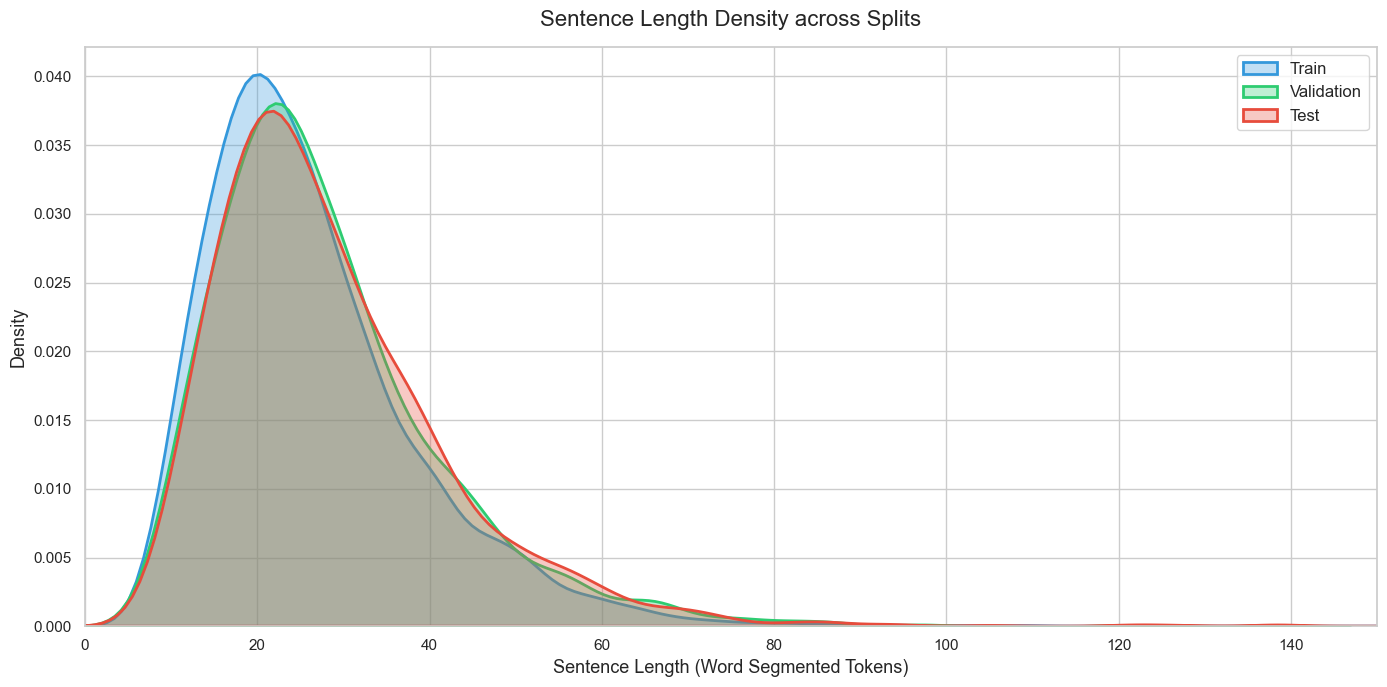

In [48]:
plt.figure(figsize=(14, 7))
colors = ["#3498db", "#2ecc71", "#e74c3c"]

for i, (name, sents) in enumerate([("Train", train_sents), ("Validation", dev_sents), ("Test", test_sents)]):
    lengths = [len(s) for s in sents]
    sns.kdeplot(lengths, fill=True, label=name, color=colors[i], alpha=0.3, linewidth=2)

plt.title("Sentence Length Density across Splits", fontsize=16, pad=15)
plt.xlabel("Sentence Length (Word Segmented Tokens)", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.xlim(0, 150)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

> Phần lớn các câu có độ dài từ 10 đến 40, trên cả 3 tập dữ liệu

## 3. TRỰC QUAN HOÁ PHÂN PHỐI TẦN SUẤT CỦA CÁC NHÃN

In [49]:
def count_entities(sentences):
    """
    Count only B- tags to get the true count of entity occurrences.
    """
    entities = []
    for sent in sentences:
        for word, tag in sent:
            if tag.startswith("B-"):
                entities.append(tag[2:])  # Extract class name (e.g. LOCATION)
    return Counter(entities)

train_entities = count_entities(train_sents)
dev_entities = count_entities(dev_sents)
test_entities = count_entities(test_sents)

df_entities = pd.DataFrame({
    "Train": pd.Series(train_entities),
    "Validation": pd.Series(dev_entities),
    "Test": pd.Series(test_entities)
}).fillna(0).astype(int)

df_entities["Total"] = df_entities.sum(axis=1)
df_entities = df_entities.sort_values(by="Total", ascending=False)
df_entities

,Train,Validation,Test,Total
LOCATION,5398,2737,4441,12576
PATIENT_ID,3240,1276,2005,6521
DATE,2549,1103,1654,5306
SYMPTOM_AND_DISEASE,1439,766,1136,3341
ORGANIZATION,1137,551,771,2459
AGE,682,361,582,1625
GENDER,542,277,462,1281
NAME,349,188,318,855
JOB,205,132,173,510
TRANSPORTATION,226,87,193,506


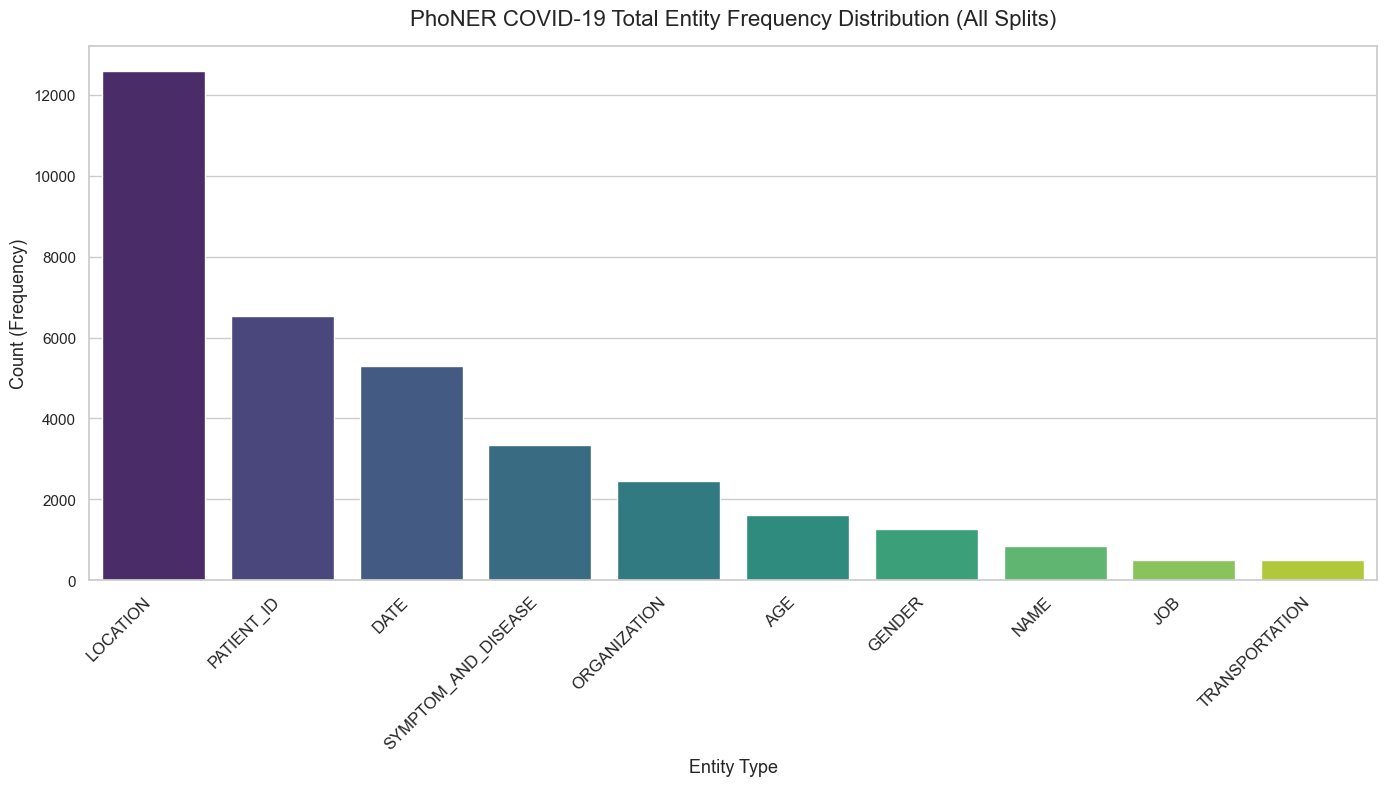

In [50]:
plt.figure(figsize=(14, 8))
palette = sns.color_palette("viridis", len(df_entities))

sns.barplot(
    x=df_entities.index,
    y=df_entities["Total"],
    palette=palette
)

plt.title("PhoNER COVID-19 Total Entity Frequency Distribution (All Splits)", fontsize=16, pad=15)
plt.xlabel("Entity Type", fontsize=13)
plt.ylabel("Count (Frequency)", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.tight_layout()
plt.show()

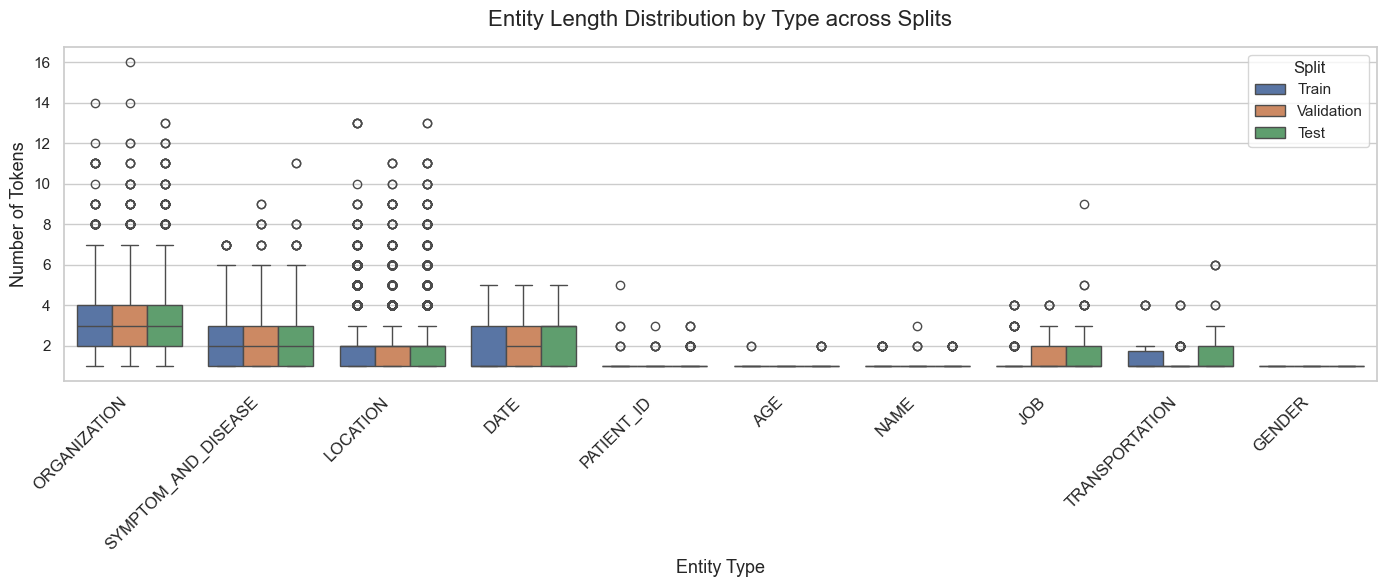

                       count      mean       std  min  25%  50%   75%   max
Type                                                                       
AGE                   1625.0  1.004923  0.070013  1.0  1.0  1.0  1.00   2.0
DATE                  5306.0  2.011685  1.019441  1.0  1.0  2.0  3.00   5.0
GENDER                1281.0  1.000000  0.000000  1.0  1.0  1.0  1.00   1.0
JOB                    510.0  1.441176  0.872788  1.0  1.0  1.0  2.00   9.0
LOCATION             12576.0  2.045881  1.343463  1.0  1.0  2.0  2.00  13.0
NAME                   855.0  1.036257  0.193198  1.0  1.0  1.0  1.00   3.0
ORGANIZATION          2459.0  3.445710  1.948639  1.0  2.0  3.0  4.00  16.0
PATIENT_ID            6521.0  1.006901  0.102641  1.0  1.0  1.0  1.00   5.0
SYMPTOM_AND_DISEASE   3341.0  2.204729  1.214923  1.0  1.0  2.0  3.00  11.0
TRANSPORTATION         506.0  1.318182  0.680380  1.0  1.0  1.0  1.75   6.0


In [51]:
def extract_full_entities(sentences):
    """
    Trích xuất toàn bộ thực thể (bao gồm cả B- và các thẻ I- đi kèm)
    để tính toán độ dài trung bình của các loại thực thể.
    """
    entities = []
    for sent in sentences:
        current_entity = []
        current_type = None
        for word, tag in sent:
            if tag.startswith("B-"):
                if current_entity:
                    entities.append(
                        (current_type, " ".join(current_entity), len(current_entity))
                    )
                current_type = tag[2:]
                current_entity = [word]
            elif tag.startswith("I-") and current_type == tag[2:]:
                current_entity.append(word)
            else:
                if current_entity:
                    entities.append(
                        (current_type, " ".join(current_entity), len(current_entity))
                    )
                    current_entity = []
                    current_type = None
        if current_entity:
            entities.append(
                (current_type, " ".join(current_entity), len(current_entity))
            )
    return entities


# Gom dữ liệu từ 3 tập
splits_data = {"Train": train_sents, "Validation": dev_sents, "Test": test_sents}
all_entities = []

for split_name, sents in splits_data.items():
    ents = extract_full_entities(sents)
    for t, w, l in ents:
        all_entities.append({"Split": split_name, "Type": t, "Phrase": w, "Length": l})

df_ents = pd.DataFrame(all_entities)

# Trực quan hóa phân bố độ dài thực thể
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_ents, x="Type", y="Length", hue="Split")
plt.title("Entity Length Distribution by Type across Splits", fontsize=16, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.ylabel("Number of Tokens", fontsize=13)
plt.xlabel("Entity Type", fontsize=13)
plt.tight_layout()
plt.show()

# Thống kê mô tả về độ dài (ví dụ: Trung bình, độ lệch chuẩn, lớn nhất)
print(df_ents.groupby("Type")["Length"].describe())

- Top 3 entities (LOCATION, PATIENT_ID, DATE) chiếm 74.5% tổng số entity
- Bottom 3 entities (NAME, JOB, TRANSPORTATION) chiếm chỉ 5.7%
- Cho thấy mất cần bằng giữa các nhãn rất lớn
- Dữ liệu chứa các nhãn được phân chia khá đồng đều giữa 3 tập dữ liệu

## 4. PHÂN BỐ TỪ VỰNG

In [52]:
# 4.1 Vocabulary Size
all_vocab = set()
for sent in train_sents + dev_sents + test_sents:
    for word, tag in sent:
        all_vocab.add(word)

vocab_size = len(all_vocab)

# Tính vocabulary độc lập cho mỗi split
train_vocab = set([word for sent in train_sents for word, _ in sent])
dev_vocab = set([word for sent in dev_sents for word, _ in sent])
test_vocab = set([word for sent in test_sents for word, _ in sent])

vocab_stats = {
    "Train": len(train_vocab),
    "Validation": len(dev_vocab),
    "Test": len(test_vocab),
    "Total (Union)": vocab_size,
    r"Train $\cap$ Validation": len(train_vocab & dev_vocab),
    r"Train $\cap$ Test": len(train_vocab & test_vocab),
    r"Train $\cap$ Validation $\cap$ Test": len(train_vocab & dev_vocab & test_vocab),
}

vocab_stats = {
    "Train": len(train_vocab),
    "Validation": len(dev_vocab),
    "Test": len(test_vocab),
    "Total (Union)": vocab_size,
    r"Train $\cap$ Validation": len(train_vocab & dev_vocab),
    r"Train $\cap$ Test": len(train_vocab & test_vocab),
    r"Train $\cap$ Validation $\cap$ Test": len(train_vocab & dev_vocab & test_vocab),
}

md = "### Vocabulary Statistics\n\n"
for key, val in vocab_stats.items():
    md += f"- {key}: **{val:,}**\n"

display(Markdown(md))

### Vocabulary Statistics

- Train: **5,166**
- Validation: **4,282**
- Test: **5,434**
- Total (Union): **7,887**
- Train $\cap$ Validation: **3,081**
- Train $\cap$ Test: **3,517**
- Train $\cap$ Validation $\cap$ Test: **2,628**


**Nhận xét**

Từ vựng của ba tập dữ liệu có mức độ chồng lấp tương đối cao với **2,650 từ xuất hiện trong cả Train, Validation và Test**. Tuy nhiên, Validation và Test vẫn chứa nhiều từ không xuất hiện trong Train (OOV), lần lượt khoảng **1,272** và **2,012 từ**.

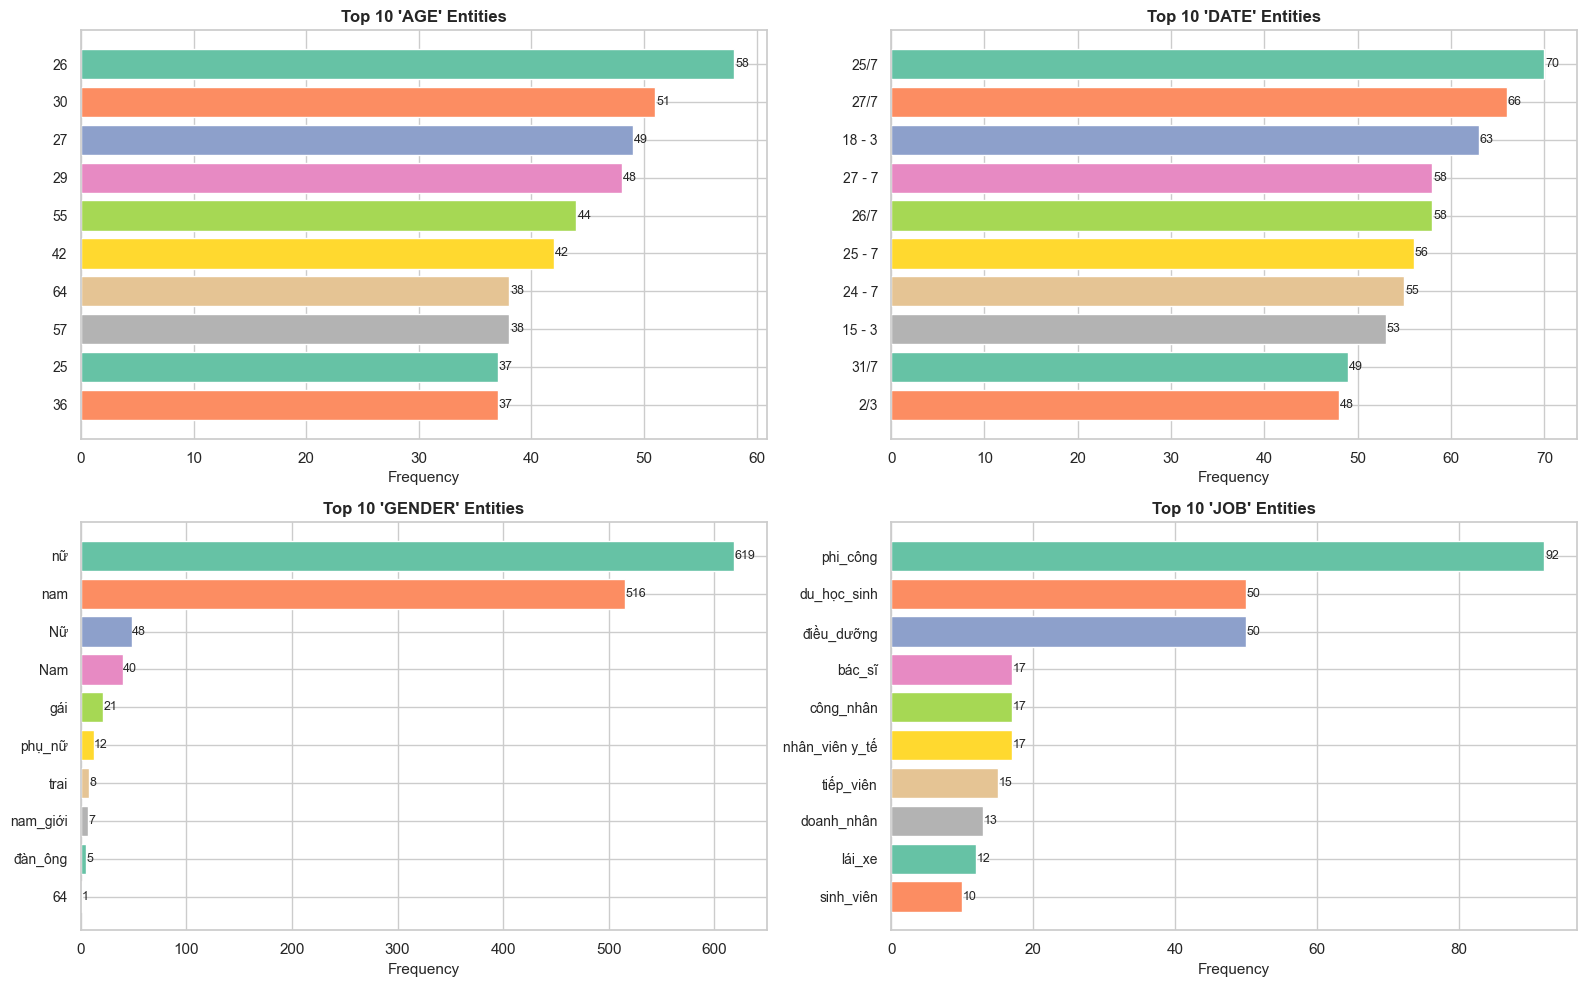

In [53]:
# 4.2 Top Frequent Words by Entity Type
entity_words = defaultdict(Counter)

for sent in train_sents + dev_sents + test_sents:
    current_entity_words = []
    current_entity_type = None
    
    for word, tag in sent:
        if tag.startswith("B-"):
            if current_entity_type:
                entity_phrase = " ".join(current_entity_words)
                entity_words[current_entity_type][entity_phrase] += 1
            current_entity_type = tag[2:]
            current_entity_words = [word]
        elif tag.startswith("I-") and tag[2:] == current_entity_type:
            current_entity_words.append(word)
        else:
            if current_entity_type:
                entity_phrase = " ".join(current_entity_words)
                entity_words[current_entity_type][entity_phrase] += 1
            current_entity_type = None
            current_entity_words = []
    
    if current_entity_type:
        entity_phrase = " ".join(current_entity_words)
        entity_words[current_entity_type][entity_phrase] += 1

# Visualize top words per entity type
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (entity_type, counter) in enumerate(sorted(entity_words.items())):
    if idx >= 4:
        break
    
    top_phrases = counter.most_common(10)
    phrases, counts = zip(*top_phrases)
    
    ax = axes[idx]
    palette = sns.color_palette("Set2", len(phrases))
    ax.barh(range(len(phrases)), counts, color=palette)
    ax.set_yticks(range(len(phrases)))
    ax.set_yticklabels(phrases, fontsize=10)
    ax.set_xlabel("Frequency", fontsize=11)
    ax.set_title(f"Top 10 '{entity_type}' Entities", fontsize=12, fontweight="bold")
    ax.invert_yaxis()
    
    # Thêm giá trị lên trên các bar
    for i, count in enumerate(counts):
        ax.text(count + 0.1, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()



# 5. Phân Tích Cross-Set (Cross-set Analysis)

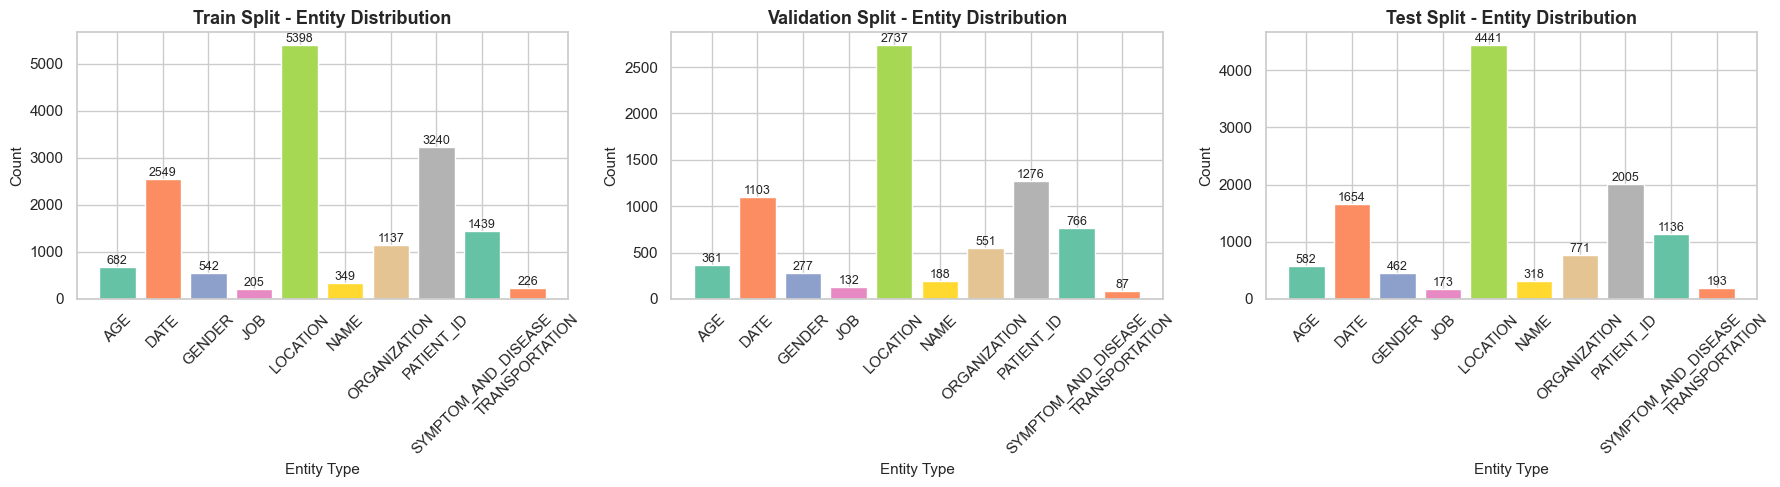

In [54]:
# 5.1 Entity Distribution Comparison across Splits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits_entities = {
    'Train': train_entities,
    'Validation': dev_entities,
    'Test': test_entities
}

all_entity_types = set()
for counter in splits_entities.values():
    all_entity_types.update(counter.keys())

all_entity_types = sorted(list(all_entity_types))

for ax, (split_name, entities) in zip(axes, splits_entities.items()):
    values = [entities.get(ent, 0) for ent in all_entity_types]
    palette = sns.color_palette("Set2", len(all_entity_types))
    
    bars = ax.bar(all_entity_types, values, color=palette)
    ax.set_title(f"{split_name} Split - Entity Distribution", fontsize=13, fontweight="bold")
    ax.set_ylabel("Count", fontsize=11)
    ax.set_xlabel("Entity Type", fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
